# 📋 Notebook 3 Conclusion

In this notebook, we:

## ✔ Trained Model
We trained an Isolation Forest model for anomaly detection.

## ✔ Tuned Hyperparameter
We evaluated different contamination values and selected the most realistic one (2%).

## ✔ Generated Predictions
Each trip was classified as:
- Normal (1)
- Anomalous (-1)

## ✔ Created Anomaly Scores
Lower scores indicate stronger anomalies.

## ✔ Saved Artifacts
- Trained model
- Scaler
- Prediction dataset

---

## Final Outcome

We now have a trained anomaly detection system capable of identifying unusual taxi trips that may indicate:

- Data quality issues
- Operational irregularities
- Suspicious behavior patterns

---
---

# 🚖 NYC Taxi Anomalous Trip Detection

## Use Case 5: Identify Anomalous Trips

### Notebook 3: Isolation Forest Model Training

---

## Objective

The objective of this notebook is to train an unsupervised machine learning model capable of identifying unusual taxi trips that may indicate:

- Data quality issues
- Operational irregularities
- Suspicious trip behavior
- Unusual revenue patterns

Unlike supervised machine learning problems, anomaly detection datasets typically do not contain labels indicating whether a trip is normal or anomalous.

Therefore, an unsupervised learning approach is required.

---

## Why Isolation Forest?

Isolation Forest is one of the most widely used anomaly detection algorithms in industry because:

- It does not require labeled data
- It scales efficiently to large datasets
- It performs well on high-dimensional data
- It can identify rare and unusual observations

The algorithm works by isolating observations through random feature selection and random split values.

Anomalous observations are easier to isolate and therefore require fewer splits compared to normal observations.

As a result, records that are isolated quickly receive higher anomaly scores.

# Step 1: Import Required Libraries

The following libraries are used for:

- Data loading
- Feature scaling
- Isolation Forest training
- Model evaluation
- Model persistence

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import joblib

# Step 2: Load Engineered Dataset

Load the feature dataset created in Notebook 2.

This dataset contains engineered features representing:

- Trip behavior
- Revenue behavior
- Route behavior
- Temporal behavior
- Operational behavior

In [3]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE5_Anomaly Detection/data/anomaly_features.parquet"
)
pd.set_option("display.max_columns", None)
print(df.shape)

df.head()

(3560826, 22)


,passenger_count,passenger_missing,trip_distance,trip_duration,speed,fare_amount,tip_amount,total_amount,fare_per_mile,fare_per_minute,tip_percentage,revenue_per_minute,extra_charges,pickup_frequency,dropoff_frequency,route_frequency,hour_sin,hour_cos,is_weekend,is_night_trip,RatecodeID,payment_type
0,1.0,0,0.97,5.550000,10.486486,7.2,3.66,15.86,7.415036,1.099237,50.826274,2.857143,8.66,94155,77513,8742,0.0,1.0,0,1,1.0,1
1,0.0,0,0.90,5.716667,9.446064,7.9,0.00,13.65,8.768036,1.176179,0.000000,2.387337,5.75,83056,86354,2781,0.0,1.0,0,1,1.0,2
2,0.0,0,1.40,8.883333,9.455910,10.7,2.50,18.95,7.637402,1.082631,23.362303,2.132968,8.25,42010,142364,3083,0.0,1.0,0,1,1.0,1
3,4.0,0,5.58,42.800000,7.822430,38.7,11.11,55.56,6.934241,0.883562,28.707269,1.298101,16.86,106731,9711,81,0.0,1.0,0,1,1.0,1
4,0.0,0,2.16,13.500000,9.600000,13.5,3.85,23.10,6.247108,0.931034,28.516406,1.710984,9.60,11583,34595,232,0.0,1.0,0,1,1.0,1


# Step 3: Validate Dataset

Before training the model, verify that:

- No missing values exist
- No infinite values exist
- All features are numerical

In [4]:
print("Missing Values:")
print(df.isna().sum().sum())

Missing Values:
0


In [5]:
print("Infinite Values:")

print(
    np.isinf(
        df.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

Infinite Values:
43903


In [6]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.isna().sum().sort_values(ascending=False).head(10)

speed                43903
passenger_count          0
passenger_missing        0
trip_distance            0
trip_duration            0
fare_amount              0
tip_amount               0
total_amount             0
fare_per_mile            0
fare_per_minute          0
dtype: int64

In [7]:
print("Zero duration trips:", (df["trip_duration"] <= 0).sum())

Zero duration trips: 43904


In [8]:
df = df[df["trip_duration"] > 0]

In [ ]:
df.info()

In [9]:
df["speed"] = df["trip_distance"] / (df["trip_duration"] / 60)

df["fare_per_minute"] = df["fare_amount"] / df["trip_duration"]

df["revenue_per_minute"] = df["total_amount"] / df["trip_duration"]

In [10]:
import numpy as np

print("Infinite values:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())
print("Missing values:", df.isna().sum().sum())

Infinite values: 0
Missing values: 0


In [12]:
df.shape

(3516922, 22)

# Step 4: Feature Scaling

The engineered features exist on very different scales.

Examples:

- trip_distance may range from 0 to 100+
- route_frequency may range from 1 to thousands
- tip_percentage may exceed 100

Without scaling, larger-valued features may dominate the anomaly detection process.

StandardScaler transforms each feature so that:

- Mean = 0
- Standard Deviation = 1

This allows all features to contribute more equally during model training.

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled.shape)

(3516922, 22)


# Step 5: Hyperparameter Tuning

We tune the most important parameter:

### contamination

This defines expected anomaly percentage.

We test multiple values and observe:

- anomaly rate
- stability
- business realism

Expected anomaly range in taxi systems:
👉 1% to 5%

In [15]:
contamination_values = [0.01, 0.02, 0.03, 0.05]

results = []

for c in contamination_values:

    model = IsolationForest(
        n_estimators=200,
        contamination=c,
        max_samples="auto",
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_scaled)

    preds = model.predict(X_scaled)

    anomaly_pct = (preds == -1).mean() * 100

    results.append((c, anomaly_pct))

# Step 6: Compare Hyperparameter Results

We compare how contamination affects anomaly detection rate.

In [16]:
pd.DataFrame(
    results,
    columns=["contamination", "anomaly_percentage"]
)

,contamination,anomaly_percentage
0,0.01,1.000022
1,0.02,2.000016
2,0.03,3.000010
3,0.05,5.000026


# Step 7: Final Model Selection

Based on:

- Stability of anomaly percentage
- Business realism
- Industry expectation (1–5% anomalies)

We select:

👉 contamination = 0.02

In [17]:
final_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    max_samples="auto",
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


# Step 8: Generate Anomaly Predictions

Model outputs:

- 1 → Normal trip
- -1 → Anomalous trip

In [18]:
df["anomaly_label"] = final_model.predict(X_scaled)

# Step 9: Anomaly Score

Lower scores = more anomalous trips

In [19]:
df["anomaly_score"] = final_model.decision_function(X_scaled)

# Step 10: Anomaly Summary

We calculate:

- total anomalies
- percentage of anomalies

In [20]:
anomaly_count = (df["anomaly_label"] == -1).sum()
total_count = len(df)

print("Total Trips:", total_count)
print("Anomalies:", anomaly_count)
print("Anomaly %:", (anomaly_count / total_count) * 100)

Total Trips: 3516922
Anomalies: 70339
Anomaly %: 2.0000159230145


# Step 11: Extract Anomalous Trips

These records will be analyzed in Notebook 4.

In [21]:
anomalies = df[df["anomaly_label"] == -1].copy()

print(anomalies.shape)
anomalies.head()

(70339, 24)


,passenger_count,passenger_missing,trip_distance,trip_duration,speed,fare_amount,tip_amount,total_amount,fare_per_mile,fare_per_minute,tip_percentage,revenue_per_minute,extra_charges,pickup_frequency,dropoff_frequency,route_frequency,hour_sin,hour_cos,is_weekend,is_night_trip,RatecodeID,payment_type,anomaly_label,anomaly_score
38,1.0,0,19.10,46.950000,24.408946,80.0,0.00,85.75,4.188262,1.703940,0.000000,1.826411,5.75,74047,14731,96,0.0,1.0,0,1,4.0,2,-1,-0.000638
50,1.0,0,18.47,43.050000,25.742160,70.0,16.34,99.78,3.789724,1.626016,23.342524,2.317770,29.78,142805,66527,757,0.0,1.0,0,1,2.0,1,-1,-0.018500
65,1.0,0,15.42,23.750000,38.955789,56.9,14.85,76.00,3.689774,2.395789,26.097960,3.200000,19.10,142805,10797,1363,0.0,1.0,0,1,1.0,1,-1,-0.008825
110,1.0,0,11.10,75.583333,8.811466,64.6,15.45,92.74,5.819296,0.854686,23.916038,1.226990,28.14,46081,1442,24,0.0,1.0,0,1,1.0,1,-1,-0.024883
146,2.0,0,19.15,27.316667,42.062233,70.0,0.00,80.19,3.655162,2.562538,0.000000,2.935570,10.19,142805,43959,627,0.0,1.0,0,1,2.0,2,-1,-0.033233


In [27]:
anomaly_rate = (df["anomaly_label"] == -1).mean() * 100

print(f"Anomaly Rate: {anomaly_rate:.2f}%")

Anomaly Rate: 2.00%


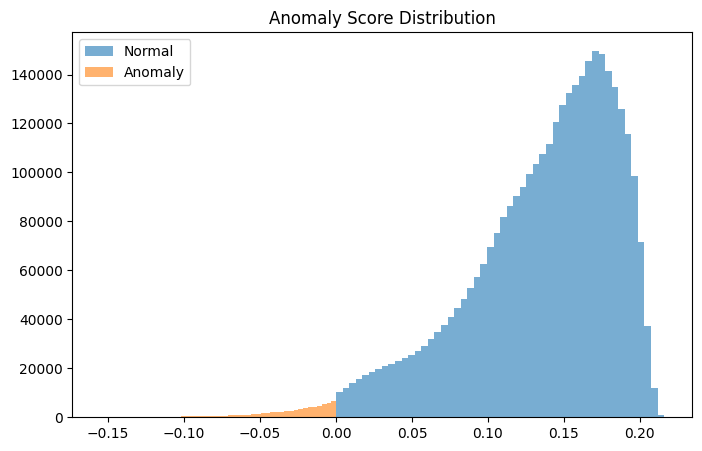

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df[df["anomaly_label"] == 1]["anomaly_score"], bins=50, alpha=0.6, label="Normal")
plt.hist(df[df["anomaly_label"] == -1]["anomaly_score"], bins=50, alpha=0.6, label="Anomaly")

plt.title("Anomaly Score Distribution")
plt.legend()
plt.show()

# Step 12: Save Trained Model

The model will be used in:

- FastAPI backend
- Streamlit dashboard

In [22]:
joblib.dump(
    final_model,
    "../models/isolation_forest.pkl"
)

['../models/isolation_forest.pkl']